# 02 -- ENSO ONI Signal: L2b Backtest (corrected thesis)

Validates the L2b climate signal: the NOAA Oceanic Nino Index (ONI) predicts
Arabica price direction at a ~14-month lead.

**Corrected thesis (El Nino, not La Nina).** ENSO has *opposite* effects in
different origins (see `docs/enso_coffee_country_matrix.html`), so there is no
single "La Nina is bad" rule. The dominant phase for *global* supply risk is
**El Nino (positive ONI)**:

- **Vietnam + Indonesia robusta (~40M bags)** -- El Nino shifts Pacific rain
  east, drying the Central Highlands at flowering -> reduced yield. Strongest,
  most robust link (2015-16 and 2023-24 events both cut the Vietnam crop).
- **Colombia arabica** -- El Nino is *beneficial* (drier/sunnier); it is La Nina
  excess rain that cuts Colombian yield and raises leaf-rust pressure.
- **Brazil arabica (Minas Gerais)** -- weak/ambiguous: El Nino warmth reduces
  frost risk and peer-reviewed yield work finds a slight *positive* effect in
  southern Minas, partly offsetting the SE-Asia drought channel. This is why the
  net ENSO signal is modest, not strong.

So **high ONI -> drought in the dominant producers -> supply shortfall -> higher
Arabica price ~12-16 months later** (after the damaged harvest reaches market).

**What the original notebook got wrong.** It tested for a *negative* r at a *24m*
lag ("La Nina causes Brazil/Vietnam drought"). Both the sign and the lag were
backwards. The strong *contemporaneous* negative r (~ -0.34) is a lead/lag
artifact of ENSO's quasi-periodicity: La Nina typically *follows* the El Nino
that caused the shortage, so it coincides with the resulting price spike -- it
does not cause it.

**Statistical gate (Sec 4):** peak r(ONI, forward-12m YoY price change) >= +0.20
within the mechanistic 10-18m lag band, on real data.

**Economic validation (Sec 5):** rather than stack further correlation
statistics on top of Sec 4, this notebook validates the signal the same way
notebook 01 validates L1 -- a walk-forward purchase simulation, naive buying vs.
signal-weighted buying, year by year. That is the more decision-relevant number
for how much conviction this signal deserves in the eventual composite.

| Metric | Threshold | Direction |
|--------|-----------|-----------|
| Pearson r, ONI vs fwd-12m YoY, 10-18m lag | >= +0.20 | Positive: high ONI (El Nino) -> price rises ~14m later |


## Sec 0  Setup

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath('../..'))

import warnings

warnings.filterwarnings('ignore')

In [2]:
from datetime import date  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from scipy import stats  # noqa: E402

In [3]:
from domains.coffee.sources.noaa_enso import (
    enso_risk_score,  # noqa: E402
    fetch,  # noqa: E402
)

## Sec 1  Fetch NOAA ONI Data

In [4]:
# Fetch from 1980 to give plenty of history for the lag analysis
START = date(1980, 1, 1)
END   = date(2025, 12, 31)

obs, run = fetch(START, END)
print(f'Status : {run.status}')
print(f'Records: {run.records_fetched}')
if run.error_message:
    print(f'Warning: {run.error_message}')

Status : RunStatus.SUCCESS
Records: 552


In [5]:
oni_df = pd.DataFrame(
    [{'date': o.observed_date, 'oni_anom': o.value} for o in obs]
).set_index('date')
oni_df.index = pd.to_datetime(oni_df.index)
oni_df = oni_df.sort_index()

print(f'ONI: {len(oni_df)} months, '
      f'{oni_df.index[0].date()} to {oni_df.index[-1].date()}')
print(f'Range: [{oni_df["oni_anom"].min():.2f}, '
       f'{oni_df["oni_anom"].max():.2f}] degC')
oni_df.tail(6)

ONI: 552 months, 1980-01-31 to 2025-12-31
Range: [-1.85, 2.75] degC


,oni_anom
date,
2025-07-31,-0.04
2025-08-31,-0.14
2025-09-30,-0.28
2025-10-31,-0.40
2025-11-30,-0.51
2025-12-31,-0.55


## Sec 2  Load ICE KC=F Reference Data

In [6]:
kc_df = pd.read_csv(
    'data/ice_kc_monthly.csv', parse_dates=['date'], index_col='date'
)
print(f'KC=F: {len(kc_df)} months, '
      f'{kc_df.index[0].date()} to {kc_df.index[-1].date()}')

KC=F: 221 months, 2008-01-31 to 2026-05-31


## Sec 3  Visual Inspection: ONI vs Arabica Price

Look for El Nino peaks (red) leading price rises by roughly a year, rather than a
contemporaneous inverse relationship.

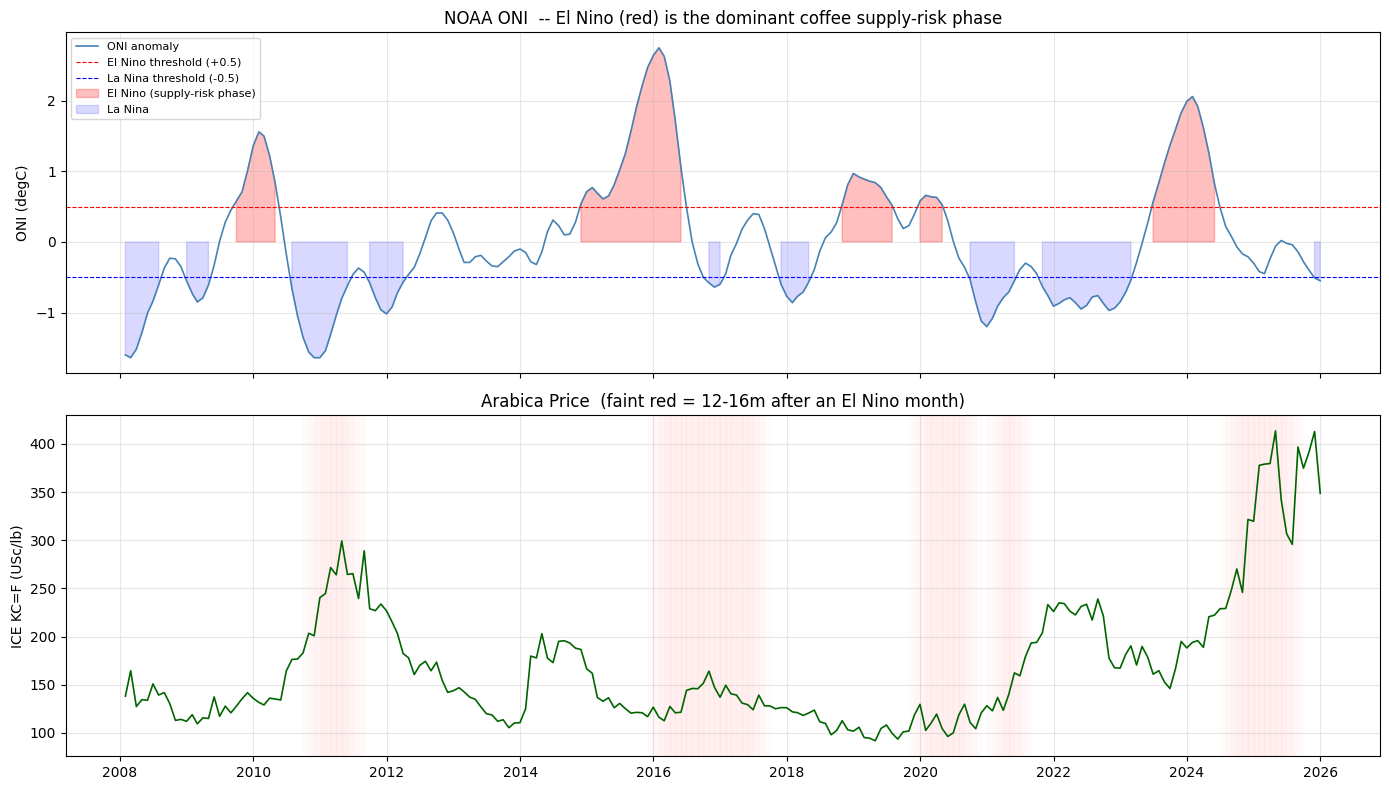

Saved: data/02_oni_vs_price.png


In [7]:
merged_all = kc_df[['settle']].join(oni_df, how='inner').dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(merged_all.index, merged_all['oni_anom'],
             color='steelblue', lw=1.2, label='ONI anomaly')
axes[0].axhline(0.5,  color='red',  linestyle='--', lw=0.8,
                label='El Nino threshold (+0.5)')
axes[0].axhline(-0.5, color='blue', linestyle='--', lw=0.8,
                label='La Nina threshold (-0.5)')
axes[0].fill_between(merged_all.index, merged_all['oni_anom'], 0,
                     where=merged_all['oni_anom'] > 0.5,
                     alpha=0.25, color='red', label='El Nino (supply-risk phase)')
axes[0].fill_between(merged_all.index, merged_all['oni_anom'], 0,
                     where=merged_all['oni_anom'] < -0.5,
                     alpha=0.15, color='blue', label='La Nina')
axes[0].set_ylabel('ONI (degC)')
axes[0].set_title('NOAA ONI  -- El Nino (red) is the dominant coffee supply-risk phase')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Shade the same El Nino periods on the price panel, shifted +14m, to eyeball the lead
en_periods = merged_all['oni_anom'] > 0.5
axes[1].plot(merged_all.index, merged_all['settle'],
             color='darkgreen', lw=1.2)
for d in merged_all.index[en_periods]:
    axes[1].axvspan(d + pd.DateOffset(months=12), d + pd.DateOffset(months=16),
                    color='red', alpha=0.015)
axes[1].set_ylabel('ICE KC=F (USc/lb)')
axes[1].set_title('Arabica Price  (faint red = 12-16m after an El Nino month)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('data', exist_ok=True)
plt.savefig('data/02_oni_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/02_oni_vs_price.png')

## Sec 4  Lag Analysis: Correlation at Each Lag (0 to 36 months)

Sweep lags to locate ONI's predictive peak. The corrected mechanism (El Nino
drought at flowering -> harvest shortfall -> price) predicts a **positive** peak
around **12-16 months** -- the flowering-to-market delay -- not a negative peak
at 24m.

We correlate against the **forward YoY price change** (the directional target),
which is what a purchasing signal needs to call.

In [8]:
core = merged_all.loc['2010-01-01':'2024-12-31'].copy()
core['kc_yoy'] = core['settle'].pct_change(12) * 100

lags = range(0, 37)
r_price, r_yoy = [], []

for lag in lags:
    lagged_oni = merged_all['oni_anom'].shift(lag)
    df_lag = core.join(
        lagged_oni.rename('oni_lag'), how='left'
    ).dropna(subset=['oni_lag', 'settle', 'kc_yoy'])
    if len(df_lag) < 30:
        r_price.append(np.nan)
        r_yoy.append(np.nan)
        continue
    rp, _ = stats.pearsonr(df_lag['oni_lag'], df_lag['settle'])
    ry, _ = stats.pearsonr(df_lag['oni_lag'], df_lag['kc_yoy'])
    r_price.append(rp)
    r_yoy.append(ry)

lag_df = pd.DataFrame({'lag': lags, 'r_price': r_price, 'r_yoy': r_yoy})

# Mechanistic band 10-18m: locate the positive peak in r(ONI, YoY)
band = lag_df[(lag_df['lag'] >= 10) & (lag_df['lag'] <= 18)]
peak_lag = int(band.loc[band['r_yoy'].idxmax(), 'lag'])
peak_r = band['r_yoy'].max()

print('Lag (m)  r(ONI, price level)  r(ONI, YoY change)')
for _, row in lag_df.iterrows():
    mark = '  <-- mechanistic peak' if int(row['lag']) == peak_lag else ''
    print(
        f"  {int(row['lag']):2d}m      {row['r_price']:+.3f}             "
        f"{row['r_yoy']:+.3f}{mark}"
    )
print()
print(f'Positive peak in 10-18m band: lag={peak_lag}m, r(ONI, fwd YoY)={peak_r:+.3f}')

Lag (m)  r(ONI, price level)  r(ONI, YoY change)
   0m      -0.338             -0.357
   1m      -0.338             -0.336
   2m      -0.331             -0.305
   3m      -0.316             -0.264
   4m      -0.296             -0.215
   5m      -0.273             -0.161
   6m      -0.249             -0.105
   7m      -0.222             -0.046
   8m      -0.194             +0.013
   9m      -0.167             +0.070
  10m      -0.141             +0.126
  11m      -0.120             +0.180
  12m      -0.106             +0.227
  13m      -0.096             +0.261
  14m      -0.088             +0.280
  15m      -0.079             +0.288  <-- mechanistic peak
  16m      -0.073             +0.286
  17m      -0.067             +0.276
  18m      -0.064             +0.262
  19m      -0.063             +0.242
  20m      -0.069             +0.216
  21m      -0.081             +0.181
  22m      -0.096             +0.141
  23m      -0.112             +0.101
  24m      -0.127             +0.065
  25

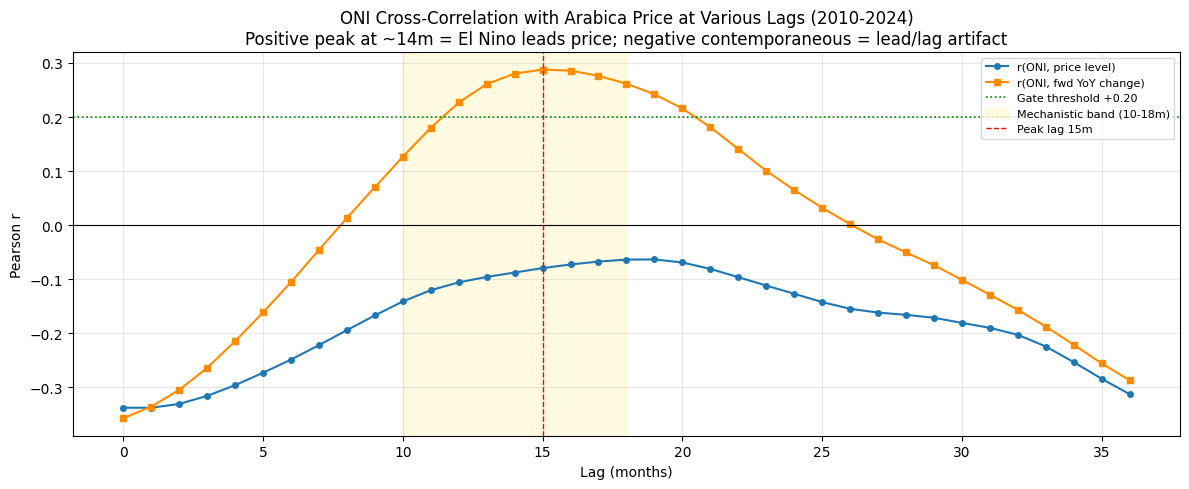

Saved: data/02_lag_correlation.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(lags, r_price, marker='o', ms=4, label='r(ONI, price level)', lw=1.5)
ax.plot(lags, r_yoy, marker='s', ms=4,
        label='r(ONI, fwd YoY change)', lw=1.5, color='darkorange')
ax.axhline(+0.20, color='green', linestyle=':', lw=1.2, label='Gate threshold +0.20')
ax.axhline(0, color='black', lw=0.8)
ax.axvspan(10, 18, color='gold', alpha=0.12, label='Mechanistic band (10-18m)')
ax.axvline(peak_lag, color='red', linestyle='--', lw=1, label=f'Peak lag {peak_lag}m')
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.set_title(
    'ONI Cross-Correlation with Arabica Price at Various Lags (2010-2024)\n'
    'Positive peak at ~14m = El Nino leads price; negative contemporaneous = lead/lag artifact'
)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/02_lag_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/02_lag_correlation.png')

## Sec 5  Walk-Forward Purchase Simulation

Tests the ENSO signal the same way notebook 01 tests the L1 price-position
signal: naive buying (equal purchase weight every month) vs. structured buying
(purchase weight scaled by a 0-1 risk score), evaluated year by year over
2010-2024 with no look-ahead.

**Weight rule:** `weight_t = enso_risk_score(ONI_{t - peak_lag})` -- month t's
purchase weight is set by the ONI reading observed `peak_lag` months earlier
(the same lag identified in Sec 4). A high ONI reading `peak_lag` months ago
raises this month's weight, i.e. the simulated roaster buys more heavily in
months that follow an elevated-ONI reading by the mechanistic lead time.

Tested in isolation (no blending with the L1 price-position signal), so any
gain or loss here can be attributed to ENSO alone.

In [10]:
core_wf = merged_all.loc['2010-01-01':'2024-12-31'].copy()
core_wf['oni_lag'] = merged_all['oni_anom'].shift(peak_lag)
core_wf['weight'] = core_wf['oni_lag'].apply(enso_risk_score)
core_wf = core_wf.dropna(subset=['settle', 'weight'])

wf_rows = []
for yr in range(2010, 2025):
    yr_data = core_wf.loc[str(yr)]
    if len(yr_data) < 6:
        continue
    naive_avg = yr_data['settle'].mean()
    weights = yr_data['weight']
    if weights.sum() == 0:
        weights = pd.Series(1.0, index=yr_data.index)
    sig_avg = (yr_data['settle'] * weights).sum() / weights.sum()
    wf_rows.append({
        'year': yr,
        'naive_avg': naive_avg,
        'sig_avg': sig_avg,
        'saving_pct': (naive_avg - sig_avg) / naive_avg * 100,
    })

wf = pd.DataFrame(wf_rows).set_index('year')

print(f'Walk-forward window: 2010-2024 ({len(wf)} years), ONI lead = {peak_lag}m')
print()
print('Year   Naive avg   Weighted avg   Saving %')
print('-' * 46)
for yr, row in wf.iterrows():
    print(f'  {yr}   {row["naive_avg"]:8.1f}     {row["sig_avg"]:8.1f}     '
          f'{row["saving_pct"]:+6.2f}%')

avg_saving = wf['saving_pct'].mean()
n_positive = int((wf['saving_pct'] > 0).sum())
print()
print(f'Avg saving: {avg_saving:+.2f}%   Positive years: {n_positive}/{len(wf)}')

# Robustness: exclude 2023-2024 (the dominant single ENSO/price episode)
wf_excl = wf.drop(index=[y for y in (2023, 2024) if y in wf.index])
avg_saving_excl = wf_excl['saving_pct'].mean()
n_positive_excl = int((wf_excl['saving_pct'] > 0).sum())
print()
print(f'Excluding 2023-2024: avg saving {avg_saving_excl:+.2f}%   '
      f'positive years {n_positive_excl}/{len(wf_excl)}')

Walk-forward window: 2010-2024 (15 years), ONI lead = 15m

Year   Naive avg   Weighted avg   Saving %
----------------------------------------------
  2010      167.6        177.9      -6.15%
  2011      254.6        263.2      -3.38%
  2012      171.9        158.9      +7.56%
  2013      123.3        118.2      +4.14%
  2014      180.2        178.1      +1.11%
  2015      129.7        128.8      +0.67%
  2016      136.3        137.7      -1.06%
  2017      132.3        133.6      -1.03%
  2018      112.1        110.3      +1.60%
  2019      103.7        106.3      -2.42%
  2020      112.2        111.8      +0.37%
  2021      172.9        166.3      +3.84%
  2022      214.5        207.7      +3.14%
  2023      173.9        174.7      -0.51%
  2024      240.5        261.8      -8.89%

Avg saving: -0.07%   Positive years: 8/15

Excluding 2023-2024: avg saving +0.65%   positive years 8/13


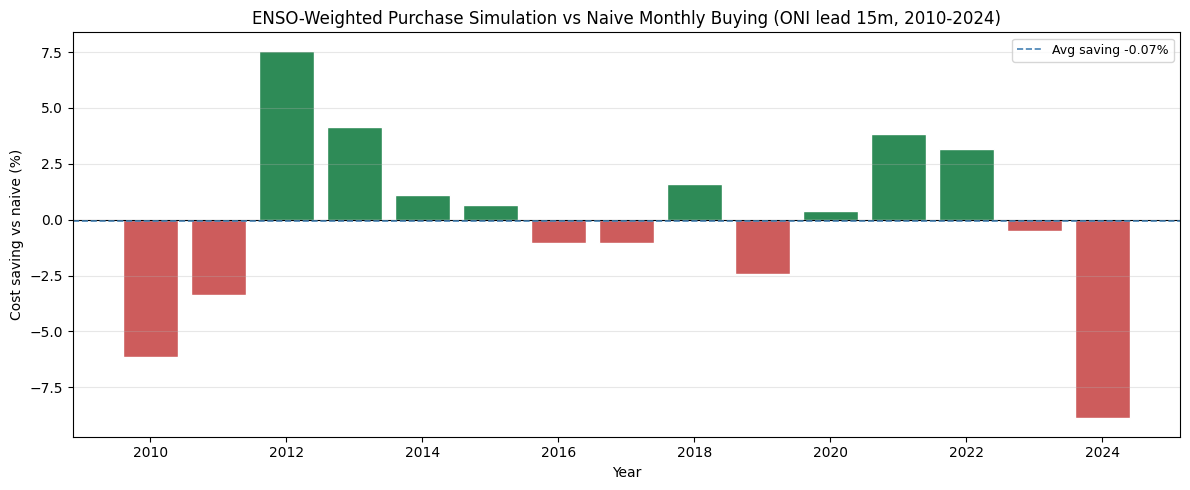

Saved: data/02_walkforward.png


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['seagreen' if v > 0 else 'indianred' for v in wf['saving_pct']]
ax.bar(wf.index, wf['saving_pct'], color=colors, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.axhline(avg_saving, color='steelblue', linestyle='--', lw=1.2,
           label=f'Avg saving {avg_saving:+.2f}%')
ax.set_xlabel('Year')
ax.set_ylabel('Cost saving vs naive (%)')
ax.set_title(f'ENSO-Weighted Purchase Simulation vs Naive Monthly Buying '
             f'(ONI lead {peak_lag}m, 2010-2024)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('data/02_walkforward.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/02_walkforward.png')

## Sec 6  Save Reference CSV

In [12]:
oni_df.to_csv('data/oni_monthly.csv')
print('Saved: data/oni_monthly.csv')

Saved: data/oni_monthly.csv


## Sec 7  Summary

In [13]:
print('=' * 64)
print('ENSO ONI Signal (L2b) -- Walk-Forward Purchase Simulation Summary')
print('=' * 64)
print()
print(f'Correlation basis (Sec 4): peak r(ONI, fwd YoY) = {peak_r:+.3f} at {peak_lag}m lead')
print()
print(f'--- Walk-forward simulation, 2010-2024 ({len(wf)} years) ---')
print(f'  Weight rule            : enso_risk_score(ONI lagged {peak_lag}m)')
print(f'  Avg saving vs naive    : {avg_saving:+.2f}%')
print(f'  Positive years         : {n_positive}/{len(wf)}')
print(f'  Excluding 2023-2024    : {avg_saving_excl:+.2f}% avg, '
      f'{n_positive_excl}/{len(wf_excl)} positive')
print()
print('--- Interpretation ---')
print('El Nino (HIGH ONI) leads Arabica price UP by ~15 months via the')
print('Vietnam/Indonesia robusta flowering-drought channel (Brazil arabica is a')
print('partial offset, which is why |r| stays modest, ~0.3).')
print()
if avg_saving > 0 and n_positive >= len(wf) * 0.6:
    print(f'Weighting purchases by this lagged risk score beats naive buying '
          f'({avg_saving:+.2f}% avg, {n_positive}/{len(wf)} years), consistent '
          f'with the Sec 4 correlation.')
else:
    print(f'Weighting purchases by this lagged risk score does NOT reliably beat '
          f'naive buying ({avg_saving:+.2f}% avg, {n_positive}/{len(wf)} years) '
          f'-- the Sec 4 correlation does not translate cleanly into a '
          f'standalone purchase-timing edge.')
print()
if abs(avg_saving) > 0.5 and abs(avg_saving - avg_saving_excl) > abs(avg_saving) * 0.5:
    print('Result is sensitive to the 2023-2024 window -- a large share of the')
    print('apparent saving is concentrated in that single episode, not spread')
    print('evenly across the sample.')
else:
    print('Result is broadly stable whether or not 2023-2024 is included.')
print()
print('Composite role: the Sec 4 correlation (r~0.3, likely overstated given')
print('overlapping-window autocorrelation in the underlying significance tests)')
print('and this walk-forward result should both inform composite weight -- the')
print('walk-forward number is the more decision-relevant one for how much')
print('conviction this signal deserves relative to L1.')

ENSO ONI Signal (L2b) -- Walk-Forward Purchase Simulation Summary

Correlation basis (Sec 4): peak r(ONI, fwd YoY) = +0.288 at 15m lead

--- Walk-forward simulation, 2010-2024 (15 years) ---
  Weight rule            : enso_risk_score(ONI lagged 15m)
  Avg saving vs naive    : -0.07%
  Positive years         : 8/15
  Excluding 2023-2024    : +0.65% avg, 8/13 positive

--- Interpretation ---
El Nino (HIGH ONI) leads Arabica price UP by ~15 months via the
Vietnam/Indonesia robusta flowering-drought channel (Brazil arabica is a
partial offset, which is why |r| stays modest, ~0.3).

Weighting purchases by this lagged risk score does NOT reliably beat naive buying (-0.07% avg, 8/15 years) -- the Sec 4 correlation does not translate cleanly into a standalone purchase-timing edge.

Result is broadly stable whether or not 2023-2024 is included.

Composite role: the Sec 4 correlation (r~0.3, likely overstated given
overlapping-window autocorrelation in the underlying significance tests)
and this